# Gradient-Boosted Baseline (XGBoost on lag + calendar features)

This notebook generates the gradient-boosted test forecasts required for the F1 degradation curve, for **SA1** and **NSW1** separately. The model is an XGBoost regressor trained once on the training window, using lag values of the demand series (up to one day back, plus 2-day, 3-day and weekly lags) and calendar features (hour, minute, day-of-week, month).

The model is frozen: it is fitted once and never retrained. It is then rolled forward through the whole test stream as a **recursive multi-step forecast** — each lag is filled from the model's own earlier forecasts, never from a test observation. This mirrors the classical baseline's frozen multi-step forecast and keeps the three F1 lines comparable.

## Key concepts

**Degradation curve (F1)** — A frozen model is trained (or defined) once and never updated, even as new data arrives. "Degradation" is what happens when the real-world process drifts away from what that frozen model assumes, so its forecast error grows over time. The F1 curve is a plot of a rolling error metric against time for each frozen baseline; a rising line means the model is degrading (a sign of concept drift), a flat line means it's still keeping pace. This notebook produces the gradient-boosted line of that curve — the seasonal-naive line lives in [`seasonal_naive_baseline.ipynb`](seasonal_naive_baseline.ipynb) and the classical line in [`dhr_arima_real.py`](../../src/drift_lab/forecasting/classical-model/dhr_arima_real.py).

**Gradient-boosted forecaster** — An XGBoost regressor fitted on features built from the response series only: `lag_k` = the value `k` intervals before the forecast point, plus calendar columns. Because every lag references a timestamp strictly before the forecast point, the model never looks ahead and can be fitted once on the training window and then rolled forward untouched (see [`xgboost_forecaster.py`](../../src/drift_lab/forecasting/xgboost_forecaster.py) and the leakage rule in `docs/interfaces.md`).

**Recursive multi-step** — At the first test interval the lag features come from the real observed history up to the train/test boundary (training window plus the calibration period). From then on the model consumes its own forecasts as the lags roll forward, so the frozen model is genuinely extrapolating rather than re-anchoring on recent actuals.

**MAE** — Mean Absolute Error, $\frac{1}{n}\sum_i |y_i - \hat{y}_i|$, measured in MW (same units as demand). It's the average size of the forecast miss.

**Rolling MAE (7-day)** — MAE recomputed on a sliding 7-day window (336 half-hourly forecasts) ending at every timestamp. This turns one summary statistic into a time series, which is what makes degradation visible. A 7-day window smooths out normal weekday/weekend noise while staying short enough to localise *when* things got worse.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from drift_lab.config import (
    DATA_DIR,
    PROCESSED_DATA_DIR,
    REGIONS,
    ROLLING_WINDOW_DAYS,
    SEASON_LENGTH,
)
from drift_lab.forecasting.xgboost_forecaster import XGBoostForecaster


## 1. Load the frozen splits for each region

The train / calibration / test split is frozen by `config.SPLIT` and was already applied by [`splits.py`](../../src/drift_lab/aemo/splits.py), which wrote `{REGION}_train.csv`, `{REGION}_calibration.csv`, and `{REGION}_test.csv` to `data/processed/`. This notebook only reads those files, for both regions in `config.REGIONS`.

In [2]:
TIMESTAMP_COLUMN = "SETTLEMENTDATE"
TARGET_COLUMN = "TOTALDEMAND"
ROLLING_WINDOW = ROLLING_WINDOW_DAYS * SEASON_LENGTH  # 336 half-hourly forecasts

MODEL_MAX_LAG = SEASON_LENGTH        # contiguous lags 1..48 (up to one day back)
MODEL_EXTRA_LAGS = (96, 144, 336)    # + 2-day, 3-day and weekly lags

# Every artefact this notebook produces (forecast CSVs + F1 figures) goes here,
# so nothing lands in the working directory. DATA_DIR is absolute, so this
# resolves the same whether the notebook is run from the repo root or from
# notebooks/exploration/.
OUTPUT_DIR = DATA_DIR / "baseline" / "xgboost"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Writing outputs to {OUTPUT_DIR}")


def load_split(region: str, split_name: str) -> pd.DataFrame:
    path = PROCESSED_DATA_DIR / f"{region}_{split_name}.csv"
    df = pd.read_csv(path)
    df[TIMESTAMP_COLUMN] = pd.to_datetime(df[TIMESTAMP_COLUMN])
    return df.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)


splits = {}

for region in REGIONS:
    splits[region] = {
        "train": load_split(region, "train"),
        "calibration": load_split(region, "calibration"),
        "test": load_split(region, "test"),
    }

    print(f"{region}")
    for split_name, split_df in splits[region].items():
        print(
            f"  {split_name}: {split_df[TIMESTAMP_COLUMN].min()} "
            f"to {split_df[TIMESTAMP_COLUMN].max()} "
            f"({len(split_df):,} rows)"
        )


Writing outputs to /Users/phong/University/Capstone/Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting/data/baseline/xgboost
SA1
  train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 (35,039 rows)
  calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 (2,880 rows)
  test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 (67,249 rows)
NSW1
  train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 (35,039 rows)
  calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 (2,880 rows)
  test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 (67,249 rows)


## 2. Fit the frozen XGBoost model and forecast the test stream

For each region the model is fitted on the **training window only**. Its lag-lookup history is then extended with the calibration observations — these sit before the test period, so this is not leakage; it just gives the recursive roll-out a real running start at the train/test boundary instead of a week of missing lags.

`predict` is then called on the test index **without** the target column, so the model runs as a recursive multi-step forecast: it never sees a test observation and fills each lag from its own earlier forecasts.

Absolute error and the 7-day rolling MAE are computed **strictly on the test slice**. Because the rolling window needs a full 336 in-test errors before it reports a value (`min_periods=ROLLING_WINDOW`), the first 335 test intervals — roughly the first week of the test stream — have no rolling MAE and appear as a gap at the left edge of the 2020 panel, exactly as in the seasonal-naive and classical baselines.

In [3]:
def xgboost_forecast(region_splits: dict[str, pd.DataFrame]) -> pd.DataFrame:
    def _series(df: pd.DataFrame) -> pd.Series:
        return pd.Series(
            df[TARGET_COLUMN].to_numpy(),
            index=pd.DatetimeIndex(df[TIMESTAMP_COLUMN]),
            name=TARGET_COLUMN,
        )

    train_y = _series(region_splits["train"])
    calibration_y = _series(region_splits["calibration"])
    test_y = _series(region_splits["test"])

    model = XGBoostForecaster(
        interval="30min",
        max_lag=MODEL_MAX_LAG,
        extra_lags=MODEL_EXTRA_LAGS,
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
    )

    # Fit on the training window only.
    model.fit(pd.DataFrame(index=train_y.index), train_y)

    # Extend the frozen model's lag-lookup history with the calibration
    # observations (before the test period -> not leakage) so the first
    # week of test lags resolve across the train -> test boundary.
    model._history = pd.concat([model._history, calibration_y])

    # Recursive multi-step forecast: no target column, so every lag is
    # filled from the model's own earlier forecasts, never from a test
    # observation. Mirrors the classical baseline's frozen forecast.
    predictions = model.predict(pd.DataFrame(index=test_y.index))

    results = pd.DataFrame(
        {
            TIMESTAMP_COLUMN: test_y.index,
            TARGET_COLUMN: test_y.to_numpy(),
            "PREDICTION": predictions,
        }
    )

    # Confirm that every test observation has a prediction.
    missing_predictions = results["PREDICTION"].isna().sum()
    if missing_predictions:
        raise ValueError(
            f"Test set contains {missing_predictions} missing predictions"
        )

    # Absolute error on the test slice only.
    results["ABSOLUTE_ERROR"] = (
        results[TARGET_COLUMN] - results["PREDICTION"]
    ).abs()

    # Rolling MAE strictly over test-period errors: the window must be full
    # (min_periods == window), so the first 335 test rows stay NaN.
    results["ROLLING_MAE_7D"] = (
        results["ABSOLUTE_ERROR"]
        .rolling(
            window=ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .mean()
    )

    return results


xgb_results = {
    region: xgboost_forecast(region_splits)
    for region, region_splits in splits.items()
}

for region, results in xgb_results.items():
    print(region)
    display(results.head())


SA1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
0,2020-03-01 00:00:00,1377.68,1387.590820,9.910820,NaN
1,2020-03-01 00:30:00,1330.34,1316.968628,13.371372,NaN
2,2020-03-01 01:00:00,1261.70,1253.418701,8.281299,NaN
3,2020-03-01 01:30:00,1182.48,1178.832397,3.647603,NaN
4,2020-03-01 02:00:00,1129.30,1131.715088,2.415088,NaN


NSW1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
0,2020-03-01 00:00:00,7019.06,7009.479492,9.580508,NaN
1,2020-03-01 00:30:00,6843.16,6829.774414,13.385586,NaN
2,2020-03-01 01:00:00,6674.67,6615.789062,58.880938,NaN
3,2020-03-01 01:30:00,6417.07,6373.796387,43.273613,NaN
4,2020-03-01 02:00:00,6221.79,6180.103027,41.686973,NaN


## 3. Inspect the forecasts and errors

In [4]:
for region, results in xgb_results.items():
    print(f"{region}")
    print(f"  Test forecasts: {len(results):,}")
    print(f"  Overall test MAE: {results['ABSOLUTE_ERROR'].mean():,.2f} MW")
    print(f"  Missing forecasts: {results['PREDICTION'].isna().sum()}")

# The leading rolling-MAE gap is checked in the validation cell below.

for region, results in xgb_results.items():
    print(region)
    display(results[[
        TIMESTAMP_COLUMN, TARGET_COLUMN, "PREDICTION",
        "ABSOLUTE_ERROR", "ROLLING_MAE_7D"
    ]].tail())


SA1
  Test forecasts: 67,249
  Overall test MAE: 219.62 MW
  Missing forecasts: 0
NSW1
  Test forecasts: 67,249
  Overall test MAE: 742.72 MW
  Missing forecasts: 0
SA1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
67244,2023-12-31 22:00:00,1285.116667,1331.625000,46.508333,266.181081
67245,2023-12-31 22:30:00,1278.321667,1293.381836,15.060169,266.224006
67246,2023-12-31 23:00:00,1249.976667,1267.776245,17.799578,266.241482
67247,2023-12-31 23:30:00,1237.001667,1246.331909,9.330243,266.234215
67248,2024-01-01 00:00:00,1306.250000,1421.949707,115.699707,266.214035


NSW1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
67244,2023-12-31 22:00:00,6968.330000,7209.348633,241.018633,820.003119
67245,2023-12-31 22:30:00,6857.930000,7129.568848,271.638848,819.788166
67246,2023-12-31 23:00:00,6782.018333,6967.735840,185.717507,819.290535
67247,2023-12-31 23:30:00,6663.935000,6808.522461,144.587461,818.397928
67248,2024-01-01 00:00:00,6633.123333,6656.697266,23.573932,817.130044


In [5]:
# Validate the rolling-MAE gap: every NaN must be one of the first
# (ROLLING_WINDOW - 1) test rows, and nothing after that may be NaN.
WARMUP_ROWS = ROLLING_WINDOW - 1  # 335

for region, results in xgb_results.items():
    rolling_mae = results["ROLLING_MAE_7D"].reset_index(drop=True)
    nan_positions = rolling_mae.index[rolling_mae.isna()]

    total_nan = len(nan_positions)
    leading_only = list(nan_positions) == list(range(total_nan))
    gap_is_warmup = total_nan == WARMUP_ROWS
    rest_all_filled = rolling_mae.iloc[WARMUP_ROWS:].notna().all()

    print(f"{region}")
    print(f"  Total NaN in ROLLING_MAE_7D: {total_nan}")
    print(f"  NaNs are exactly the first {total_nan} rows (contiguous, no gaps later): {leading_only}")
    print(f"  Gap length == ROLLING_WINDOW - 1 ({WARMUP_ROWS}): {gap_is_warmup}")
    print(f"  All rows from index {WARMUP_ROWS} onward are filled: {rest_all_filled}")
    print(f"  First filled timestamp: {results[TIMESTAMP_COLUMN].iloc[WARMUP_ROWS]}")

    assert leading_only and gap_is_warmup and rest_all_filled, (
        f"{region}: rolling-MAE NaNs are not exactly the first {WARMUP_ROWS} test rows"
    )


SA1
  Total NaN in ROLLING_MAE_7D: 335
  NaNs are exactly the first 335 rows (contiguous, no gaps later): True
  Gap length == ROLLING_WINDOW - 1 (335): True
  All rows from index 335 onward are filled: True
  First filled timestamp: 2020-03-07 23:30:00
NSW1
  Total NaN in ROLLING_MAE_7D: 335
  NaNs are exactly the first 335 rows (contiguous, no gaps later): True
  Gap length == ROLLING_WINDOW - 1 (335): True
  All rows from index 335 onward are filled: True
  First filled timestamp: 2020-03-07 23:30:00


In [6]:
# Persist the per-region forecast + rolling-MAE table so the combined F1
# notebook can overlay this line without re-running the model.
for region, results in xgb_results.items():
    out_path = OUTPUT_DIR / f"{region}_xgboost_test.csv"
    results.to_csv(out_path, index=False)
    print(f"{region}: wrote {len(results):,} rows")


SA1: wrote 67,249 rows


NSW1: wrote 67,249 rows


## 4. Plot the XGBoost F1 line

One figure is drawn per calendar year (rather than a single multi-year line) so each month is legible. The combined F1 figure overlays the seasonal-naive and classical rolling-MAE lines on the same axes, year by year.

Each figure is written to `data/baseline/xgboost/` (`f1_rolling_mae_{year}.png` for the combined panels, `f1_rolling_mae_{region}_{year}.png` for the per-region panels), alongside the `{region}_xgboost_test.csv` tables saved in section 3.

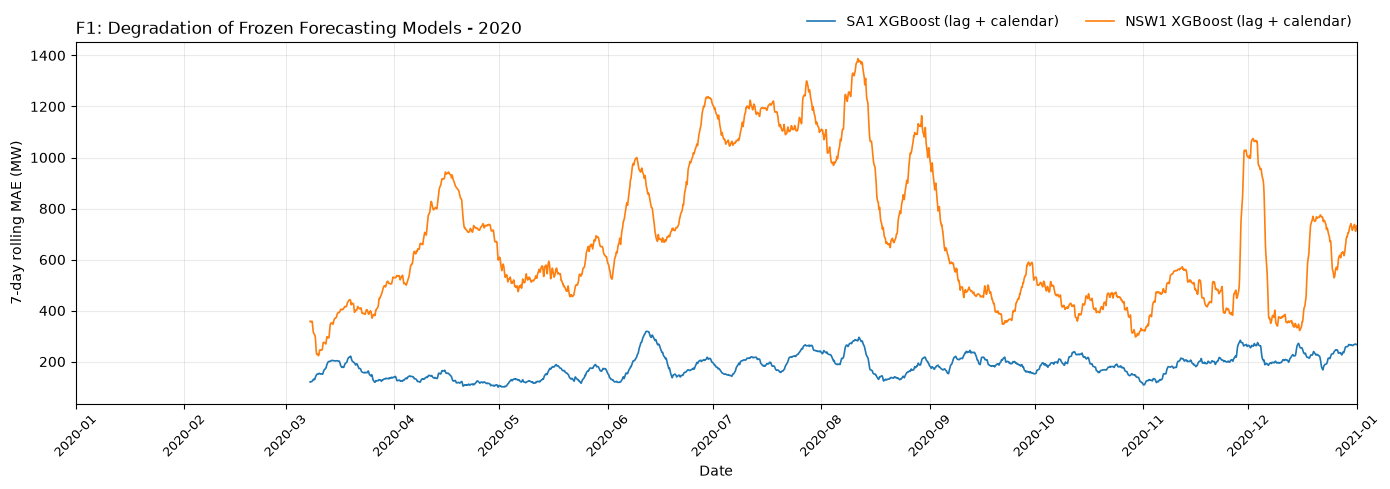

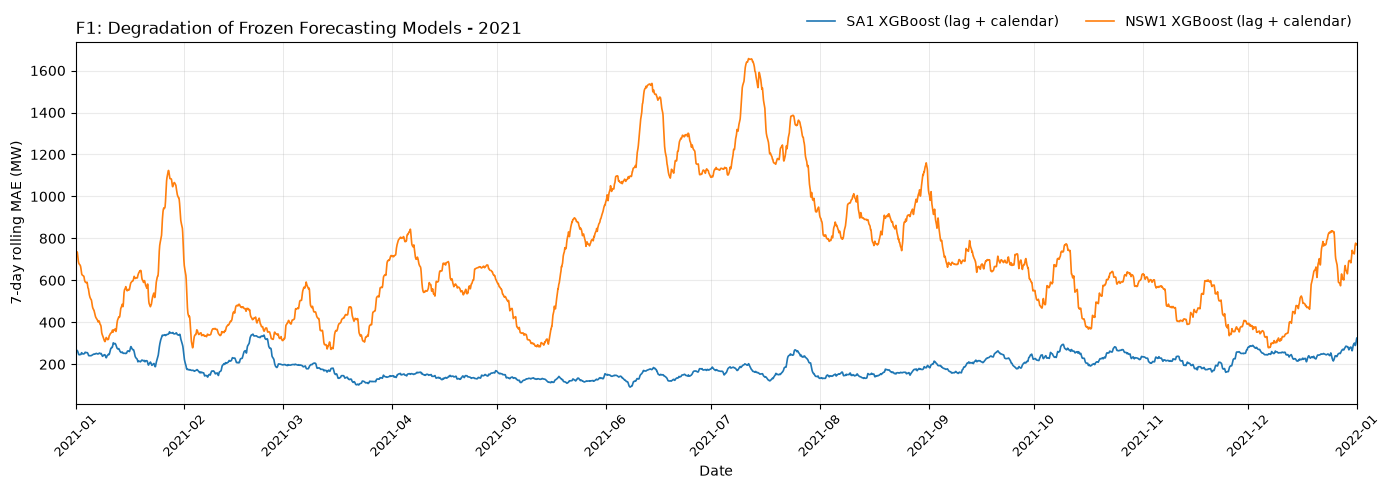

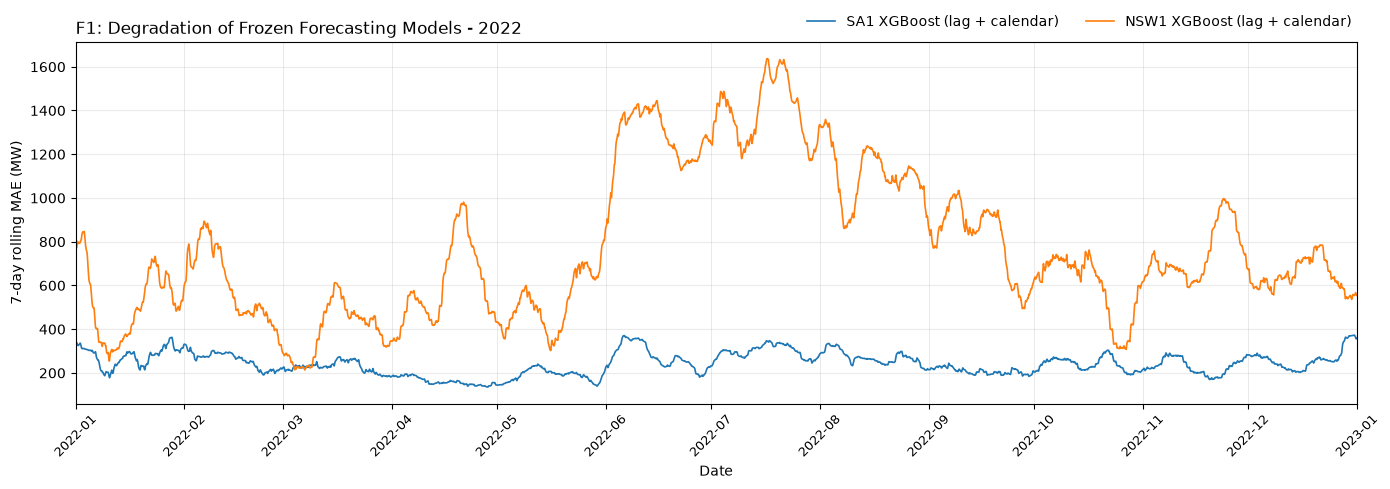

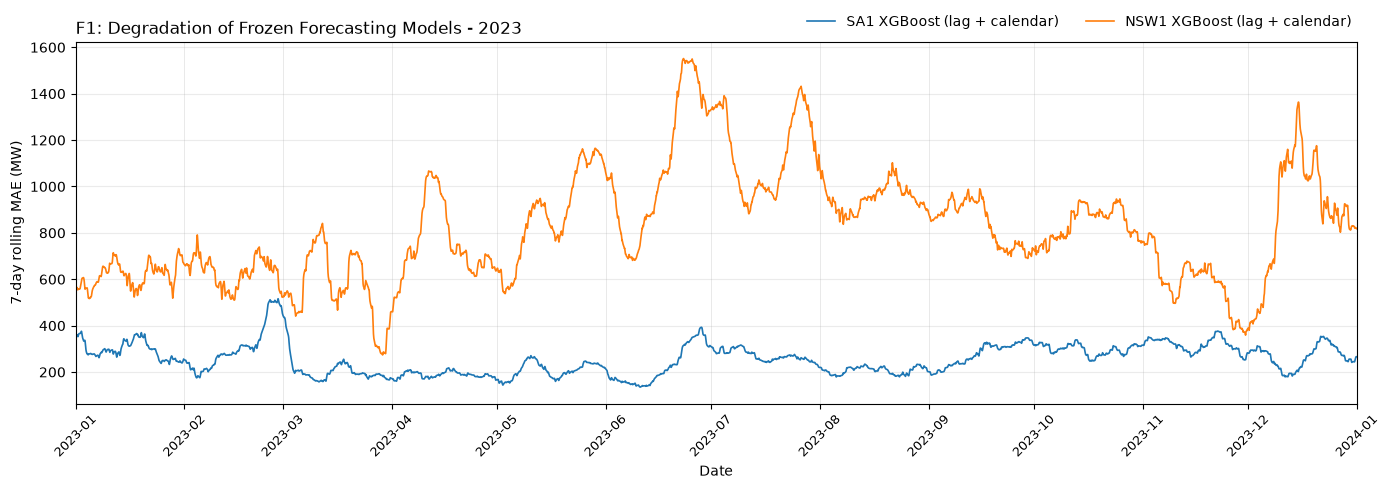

In [7]:
def format_month_axis(ax: plt.Axes, year: int) -> None:
    ax.set_xlim(pd.Timestamp(year=year, month=1, day=1), pd.Timestamp(year=year + 1, month=1, day=1))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.grid(alpha=0.25)
    ax.grid(which="major", axis="x", alpha=0.4, linewidth=0.5)


# Calendar years present anywhere in the test period, across both regions.
# AEMO timestamps an interval by its *end*, so the very last row of the
# test period is stamped 2024-01-01 00:00:00 even though it covers the
# last half-hour of 2023-12-31 - a single point, not a real 2024 year of
# data, so years with fewer than 2 rows are dropped rather than plotted.
test_years = [
    year
    for year in sorted({
        timestamp.year
        for results in xgb_results.values()
        for timestamp in results[TIMESTAMP_COLUMN]
    })
    if all(
        (results[TIMESTAMP_COLUMN].dt.year == year).sum() >= 2
        for results in xgb_results.values()
    )
]

for year in test_years:
    fig, ax = plt.subplots(figsize=(14, 5))

    for region, results in xgb_results.items():
        year_df = results[results[TIMESTAMP_COLUMN].dt.year == year]
        ax.plot(
            year_df[TIMESTAMP_COLUMN],
            year_df["ROLLING_MAE_7D"],
            label=f"{region} XGBoost (lag + calendar)",
            linewidth=1.2,
        )

    # Title on the left, legend on the same row but outside the axes on the right.
    ax.set_title(f"F1: Degradation of Frozen Forecasting Models - {year}", loc="left")
    ax.set_xlabel("Date")
    ax.set_ylabel("7-day rolling MAE (MW)")
    format_month_axis(ax, year)
    ax.legend(
        loc="lower right",
        bbox_to_anchor=(1.0, 1.02),
        ncol=len(xgb_results),
        frameon=False,
        borderaxespad=0.0,
    )

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"f1_rolling_mae_{year}.png", dpi=130, bbox_inches="tight")
    plt.show()


**What the yearly panels show:** unlike the seasonal-naive baseline (roughly flat with a recurring seasonal wobble), the frozen XGBoost forecast degrades with a **clear upward trend** — the yearly-average 7-day rolling MAE rises every year for both regions: SA1 ~183 → 193 → 242 → 255 MW (2020 → 2023), NSW1 ~683 → 697 → 767 → 816 MW. On top of that trend both lines swing seasonally, but the two regions peak in *opposite* seasons: SA1's error is worst in the spring/summer shoulder (roughly Oct–Feb) and calmest in autumn (Apr–May), whereas NSW1's is worst in **winter** (Jun–Jul) — the recursive roll-out most badly under-tracks NSW cold-weather heating demand. NSW1 sits ~3–4× above SA1 throughout, consistent with its larger absolute demand.

The single worst SA1 episode is a sharp spike to **515.9 MW on 2023-02-27** (2023 panel), ~3× its autumn baseline. NSW1's dataset maximum is **1,657 MW on 2021-07-11** — mid-winter — with a near-equal winter peak in Jun–Jul 2022 that overlaps the June 2022 NEM market-suspension window.

*Note:* the test data's last row is stamped `2024-01-01 00:00:00` — AEMO's end-of-interval label for the final half-hour of 2023-12-31, not a real 2024 observation — so no standalone 2024 panel is drawn; that single point is still counted in the "Overall test MAE" figures above.

### 4a. Per-region rolling-MAE plots

SA1 and NSW1 sit on very different demand scales, so the combined panels above compress SA1's degradation pattern. One figure per region per year, each on its own y-axis, makes each region's pattern easier to read.

Documented events from `events.csv` are overlaid in red. A precise-date event is a single dashed vertical line with its label printed horizontally next to it; a period event is two dashed lines with a light shaded band between them and its label printed horizontally, centred inside that band. The label is the `event_name` column. NEM-wide events appear on both regions' panels; region-specific events appear only on that region's. Rows with an unparseable date are skipped with a warning.

In [8]:
# Documented AEMO/AER events, used to annotate the per-region panels below.
EVENTS_PATH = next(
    path
    for path in (Path("events.csv"), Path("notebooks/exploration/events.csv"))
    if path.exists()
)
events = pd.read_csv(EVENTS_PATH)
events["start_date"] = pd.to_datetime(events["start_date"], format="%Y-%m-%d", errors="coerce")
events["end_date"] = pd.to_datetime(events["end_date"], format="%Y-%m-%d", errors="coerce")

# Drop (and flag) any row whose dates did not parse, so a typo in events.csv
# cannot break every panel.
unparseable = events[events["start_date"].isna() | events["end_date"].isna()]
if not unparseable.empty:
    print("WARNING: skipping events with unparseable dates:")
    display(unparseable[["event_id", "event_name", "start_date", "end_date"]])
    events = events.dropna(subset=["start_date", "end_date"]).reset_index(drop=True)

print(f"Loaded {len(events)} events from {EVENTS_PATH}")
display(events[["event_id", "event_name", "start_date", "end_date", "region", "event_type"]])

# Annotation rules:
#   - region == "NEM"           -> drawn on both the SA1 and the NSW1 panels
#   - region == "SA1" / "NSW1"  -> drawn only on that region's panels
#   - start_date == end_date    -> one dashed vertical line (a point in time);
#                                  the label sits next to the line
#   - start_date != end_date    -> two dashed vertical lines + a light band;
#                                  the label sits centred within the band
#   - the label is the event_name column (already unique and human-readable);
#     the event_id is not shown
EVENT_COLOR = "tab:red"
EVENT_LINE_KW = dict(color=EVENT_COLOR, linestyle="--", linewidth=1.0, alpha=0.7)
EVENT_SPAN_KW = dict(color=EVENT_COLOR, alpha=0.07, linewidth=0)
_LABEL_LEVELS = (0.96, 0.87, 0.78, 0.69, 0.60, 0.51)
_LABEL_GAP = pd.Timedelta(days=2)


def annotate_events(ax: plt.Axes, region: str, year: int) -> None:
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_end = pd.Timestamp(year=year + 1, month=1, day=1)

    in_scope = events[
        events["region"].isin([region, "NEM"])
        & (events["start_date"] < year_end)
        & (events["end_date"] >= year_start)
    ].sort_values("start_date")

    for i, (_, event) in enumerate(in_scope.iterrows()):
        is_period = event["end_date"] != event["start_date"]
        level = _LABEL_LEVELS[i % len(_LABEL_LEVELS)]
        label = event["event_name"]

        if is_period:
            for edge in (event["start_date"], event["end_date"]):
                if year_start <= edge < year_end:
                    ax.axvline(edge, **EVENT_LINE_KW)

            span_start = max(event["start_date"], year_start)
            span_end = min(event["end_date"], year_end)
            ax.axvspan(span_start, span_end, **EVENT_SPAN_KW)

            # Label kept horizontal and centred between the two period markers.
            ax.text(
                span_start + (span_end - span_start) / 2,
                level,
                label,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=6.5,
                color=EVENT_COLOR,
            )
        else:
            edge = event["start_date"]
            ax.axvline(edge, **EVENT_LINE_KW)

            # Label kept horizontal, next to the line; flip to the left near the
            # right edge so the text stays on the axes.
            near_right = edge > year_end - pd.Timedelta(days=45)
            ax.text(
                edge - _LABEL_GAP if near_right else edge + _LABEL_GAP,
                level,
                label,
                transform=ax.get_xaxis_transform(),
                ha="right" if near_right else "left",
                va="top",
                fontsize=6.5,
                color=EVENT_COLOR,
            )


Loaded 24 events from events.csv


,event_id,event_name,start_date,end_date,region,event_type
0,EVT-2020-01,NSW bushfire-related high demand - 4 Jan 2020,2020-01-04,2020-01-04,NSW1,high_demand
1,EVT-2020-02,NEM COVID-19 demand change - 1 Apr-17 May 2020,2020-04-01,2020-05-17,NEM,covid_demand_change
2,EVT-2020-04,NEM winter minimum demand record - 29 Aug 2020,2020-08-29,2020-08-29,NEM,minimum_demand
3,EVT-2020-06,SA solar-supplied minimum demand - 11 Oct 2020,2020-10-11,2020-10-11,SA1,minimum_demand
4,EVT-2020-07,NEM December solar and mild-weather demand ero...,2020-12-01,2020-12-31,NEM,gradual_solar_demand_shift
5,EVT-2021-01,SA minimum-demand intervention - 14 Mar 2021,2021-03-14,2021-03-14,SA1,minimum_demand_intervention
6,EVT-2021-02,NSW lockdown demand reduction - Aug 2021,2021-08-01,2021-08-31,NSW1,covid_demand_change
7,EVT-2021-03,NSW minimum demand record - 19 Sep 2021,2021-09-19,2021-09-19,NSW1,minimum_demand
8,EVT-2021-04,SA minimum demand record - 26 Sep 2021,2021-09-26,2021-09-26,SA1,minimum_demand
9,EVT-2021-05,NEM minimum demand record - 17 Oct 2021,2021-10-17,2021-10-17,NEM,minimum_demand


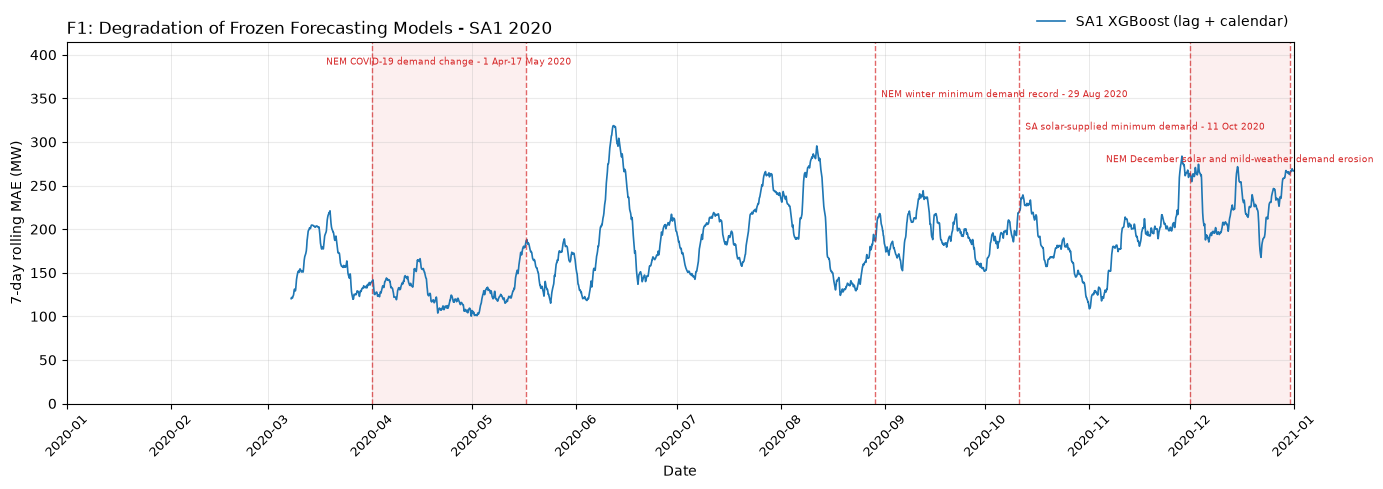

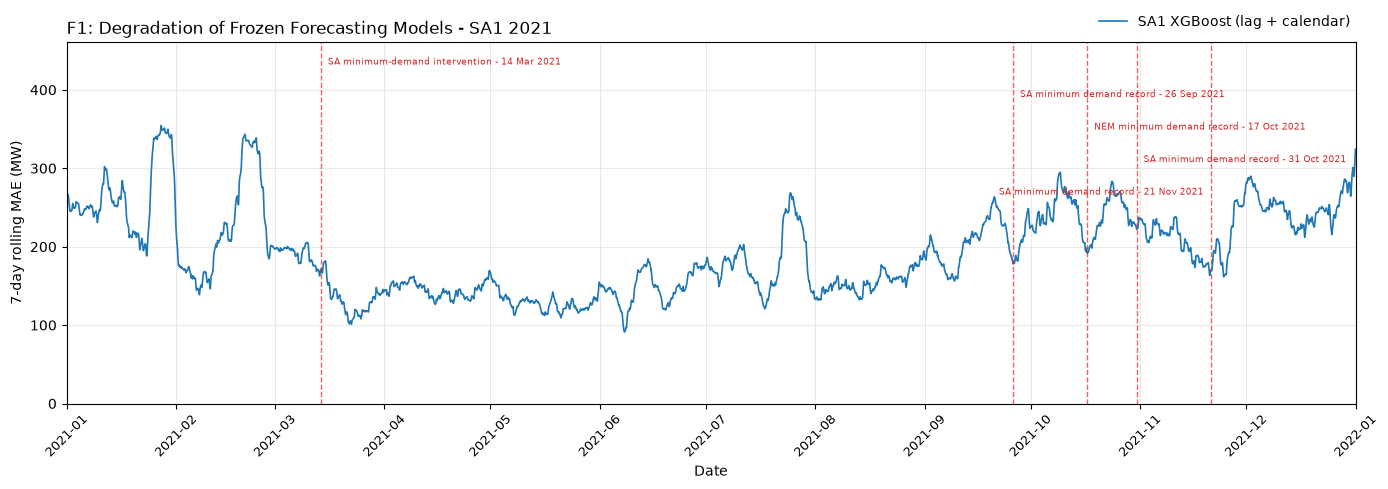

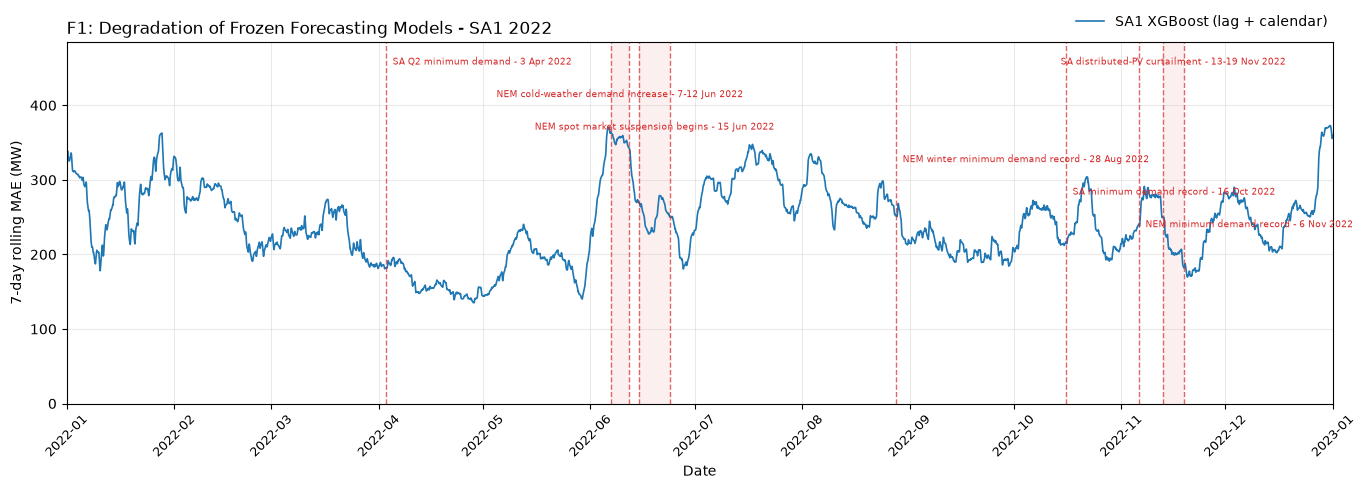

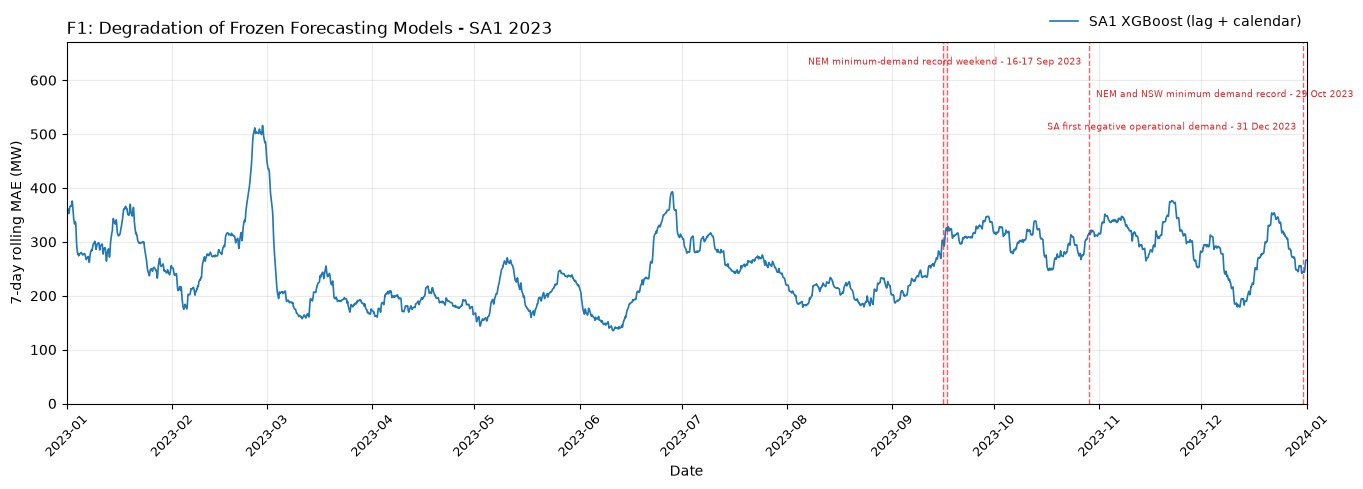

In [9]:
region_colors = {"SA1": "tab:blue", "NSW1": "tab:orange"}


def plot_region_by_year(region: str, results: pd.DataFrame, color: str) -> None:
    for year in test_years:
        year_df = results[results[TIMESTAMP_COLUMN].dt.year == year]

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(
            year_df[TIMESTAMP_COLUMN],
            year_df["ROLLING_MAE_7D"],
            label=f"{region} XGBoost (lag + calendar)",
            linewidth=1.2,
            color=color,
        )

        # Headroom above the line so the event labels stay readable.
        year_max = year_df["ROLLING_MAE_7D"].max()
        if pd.notna(year_max):
            ax.set_ylim(0, year_max * 1.30)

        annotate_events(ax, region, year)

        # Title on the left, legend on the same row but outside the axes on the right.
        ax.set_title(
            f"F1: Degradation of Frozen Forecasting Models - {region} {year}", loc="left"
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("7-day rolling MAE (MW)")
        format_month_axis(ax, year)
        ax.legend(
            loc="lower right",
            bbox_to_anchor=(1.0, 1.02),
            frameon=False,
            borderaxespad=0.0,
        )

        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f"f1_rolling_mae_{region}_{year}.png", dpi=130, bbox_inches="tight"
        )
        plt.show()


plot_region_by_year("SA1", xgb_results["SA1"], color=region_colors["SA1"])


**SA1:** the frozen model runs at ~130–180 MW rolling MAE through the calm autumn of 2020 and trends upward across the series (yearly-average rolling MAE 183 → 193 → 242 → 255 MW, 2020 → 2023). Autumn (Apr–May) consistently pulls error back toward ~128–145 MW each year, but the spring/summer shoulders climb higher every cycle. The single worst episode is a sharp spike to **515.9 MW on 2023-02-27** (2023 panel), roughly 3× the autumn baseline; Oct–Nov 2023 is the highest sustained stretch (monthly average ~300–320 MW). The rising trend plus the widening seasonal swings read as genuine degradation of the frozen model, not just a recurring seasonal effect.

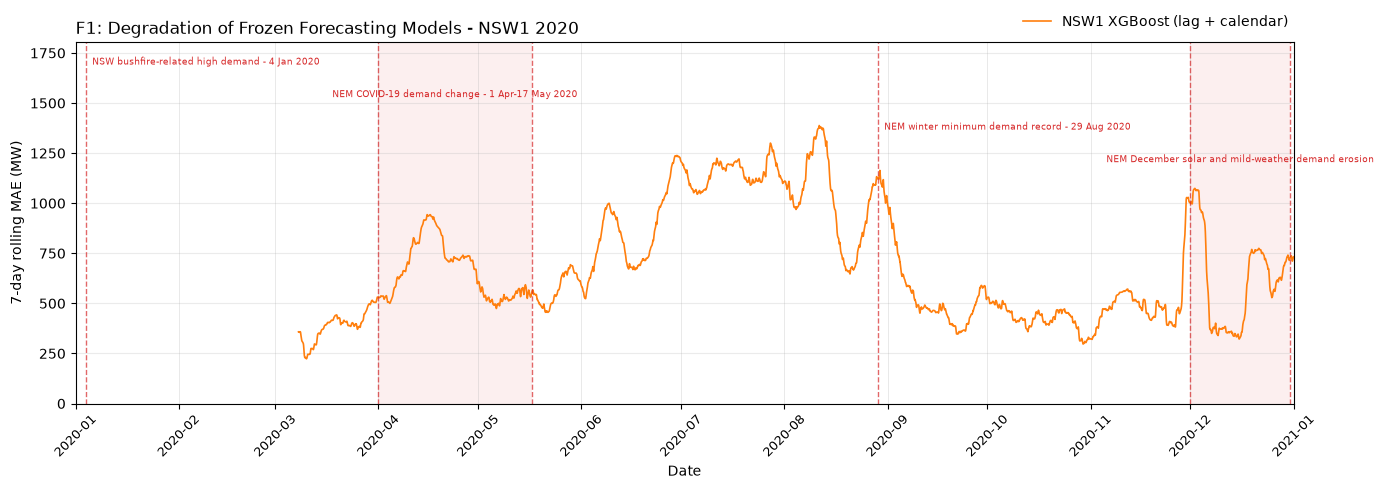

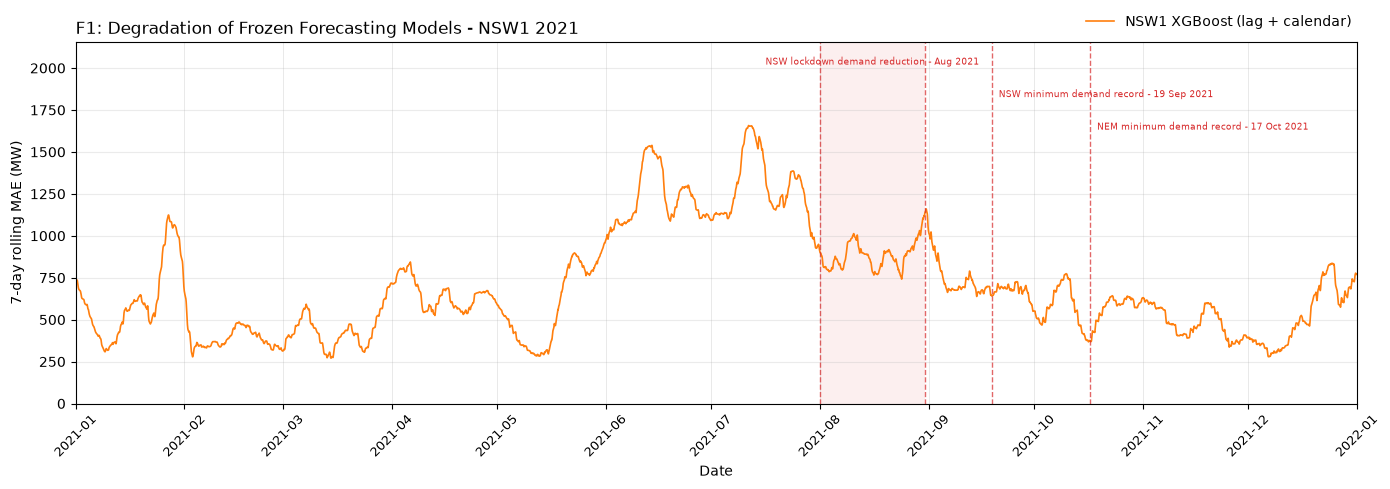

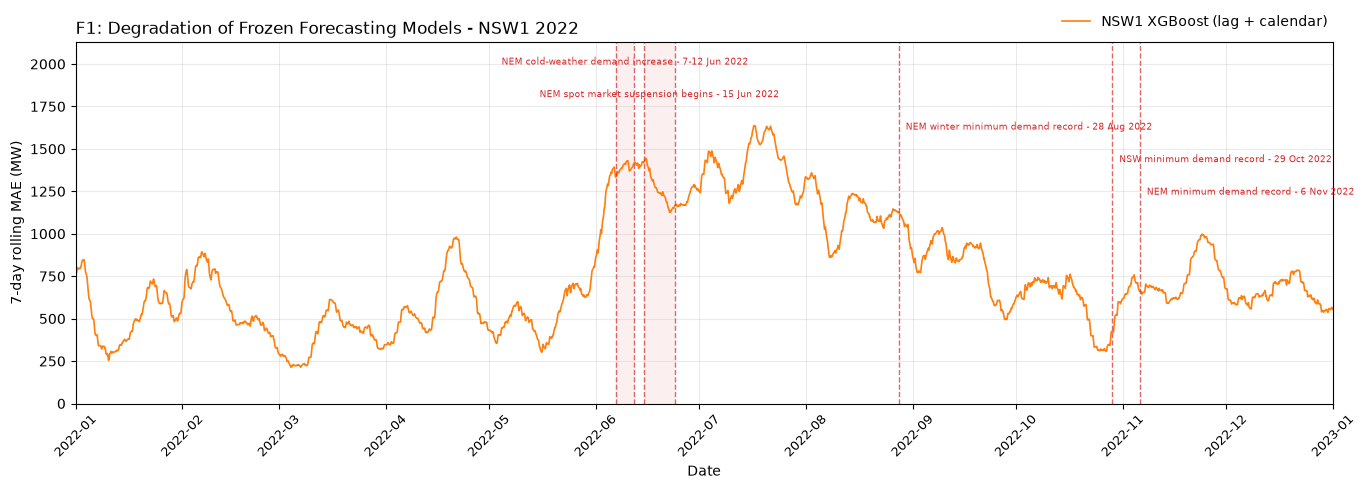

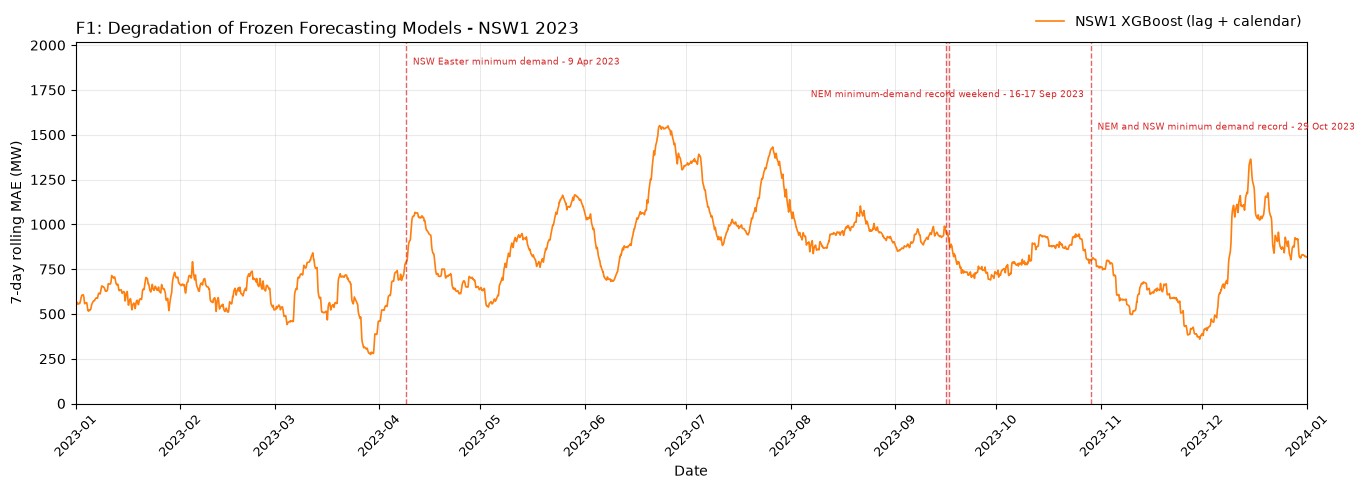

In [10]:
plot_region_by_year("NSW1", xgb_results["NSW1"], color=region_colors["NSW1"])


**NSW1:** unlike SA1 — and unlike the seasonal-naive baseline — NSW1's frozen-XGBoost error peaks in **winter**: the recursive roll-out under-predicts cold-weather heating demand. Monthly-average rolling MAE tops out in Jun–Jul (≈1,270–1,400 MW in Jul 2021 and Jun–Jul 2022) and troughs in late summer / early autumn (≈388 MW, Feb–Mar). The dataset maximum is **1,657 MW on 2021-07-11**, with a near-equal winter peak in Jun–Jul 2022 that overlaps the June 2022 NEM market-suspension window. The yearly average still trends up (683 → 697 → 767 → 816 MW, 2020 → 2023), so on top of the recurring winter spikes the frozen model is slowly losing ground year over year.

**Suggested caption:** Seven-day rolling mean absolute error (336 half-hourly forecasts) of the frozen XGBoost baseline over the test stream, for SA1 and NSW1, one panel per calendar year. The model is trained once on 2018-2019, then rolled forward as a recursive multi-step forecast. Documented events provide contextual reference points and are not treated as ground-truth changepoints.